<a href="https://colab.research.google.com/github/kailashscse2025-alt/DAA/blob/main/DAA10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


      DETERMINISTIC VS RANDOMIZED QUICK SORT
Input Type         DQS Comps   DQS Time(ms)   RQS Comps   RQS Time(ms)
------------------------------------------------------------------------
Random                 71931          12.86       68306          13.34
Sorted              12497500        3018.18       71191          48.30
Reverse             12497500        5685.54       69432          12.56
Nearly Sorted         213673          32.29       71405          12.57


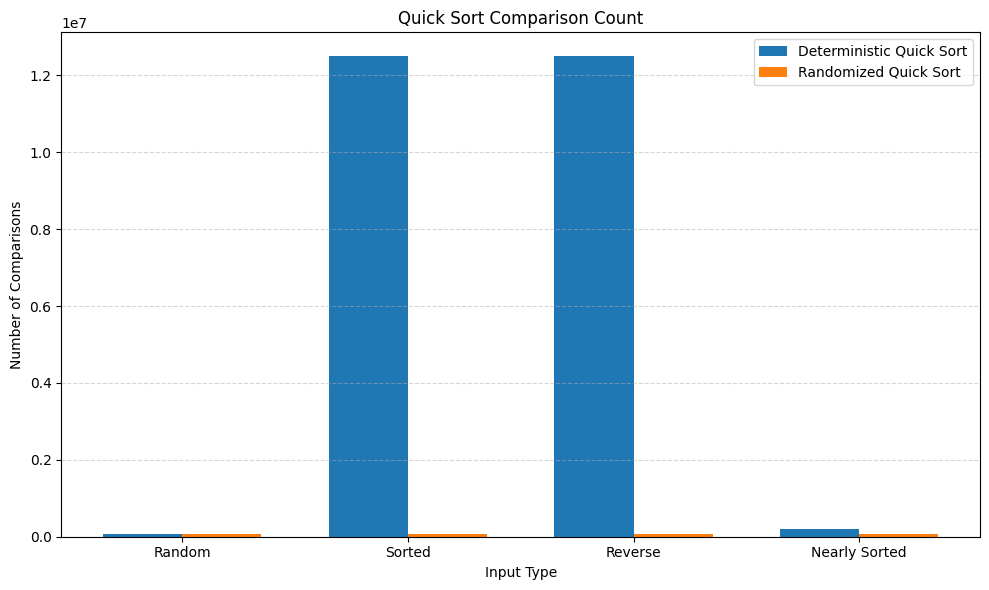

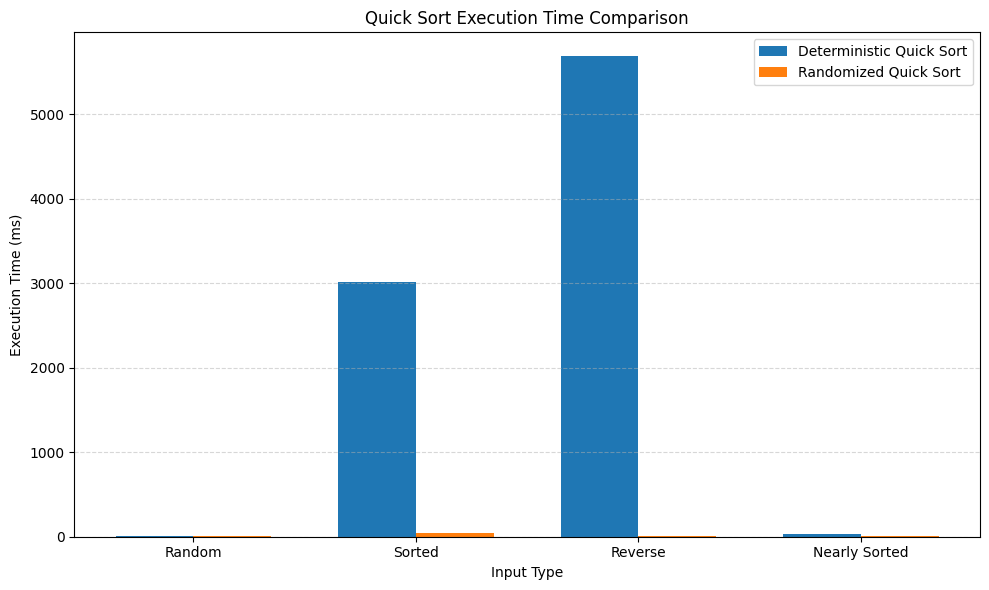

In [1]:
import random
import time
import sys
import matplotlib.pyplot as plt

sys.setrecursionlimit(20000)

comparisons = 0


# ==========================================
# PARTITION
# ==========================================

def partition(arr, low, high):

    global comparisons

    pivot = arr[high]

    i = low - 1

    for j in range(low, high):

        comparisons += 1

        if arr[j] <= pivot:

            i += 1

            arr[i], arr[j] = arr[j], arr[i]

    arr[i + 1], arr[high] = arr[high], arr[i + 1]

    return i + 1


# ==========================================
# DETERMINISTIC QUICK SORT
# ==========================================

def deterministic_quicksort(arr, low, high):

    if low < high:

        pi = partition(arr, low, high)

        deterministic_quicksort(
            arr,
            low,
            pi - 1
        )

        deterministic_quicksort(
            arr,
            pi + 1,
            high
        )


# ==========================================
# RANDOMIZED QUICK SORT
# ==========================================

def randomized_quicksort(arr, low, high):

    if low < high:

        # Random pivot
        rand_idx = random.randint(
            low,
            high
        )

        arr[rand_idx], arr[high] = (
            arr[high],
            arr[rand_idx]
        )

        pi = partition(
            arr,
            low,
            high
        )

        randomized_quicksort(
            arr,
            low,
            pi - 1
        )

        randomized_quicksort(
            arr,
            pi + 1,
            high
        )


# ==========================================
# RUN TEST
# ==========================================

def run_test(sort_fn, arr):

    global comparisons

    a = arr[:]

    comparisons = 0

    start = time.perf_counter()

    sort_fn(
        a,
        0,
        len(a) - 1
    )

    elapsed = (
        time.perf_counter() - start
    ) * 1000

    return comparisons, elapsed


# ==========================================
# INPUT SIZE
# ==========================================

N = 5000


# ==========================================
# TEST CASES
# ==========================================

test_cases = {

    "Random":
        [
            random.randint(1, 100000)
            for _ in range(N)
        ],

    "Sorted":
        list(range(N)),

    "Reverse":
        list(range(N, 0, -1)),

    "Nearly Sorted":
        list(range(N))
}


# ==========================================
# MAKE NEARLY SORTED ARRAY
# ==========================================

ns = test_cases["Nearly Sorted"]

for _ in range(N // 20):

    i = random.randint(0, N - 1)
    j = random.randint(0, N - 1)

    ns[i], ns[j] = (
        ns[j],
        ns[i]
    )


# ==========================================
# TABLE HEADER
# ==========================================

print("\n==============================================================")
print("      DETERMINISTIC VS RANDOMIZED QUICK SORT")
print("==============================================================")

print(
    f"{'Input Type':<16}"
    f"{'DQS Comps':>12}"
    f"{'DQS Time(ms)':>15}"
    f"{'RQS Comps':>12}"
    f"{'RQS Time(ms)':>15}"
)

print("-" * 72)


# Store values for graphs

case_names = []

dqs_comparisons = []
rqs_comparisons = []

dqs_times = []
rqs_times = []


# ==========================================
# RUN ALL TEST CASES
# ==========================================

for case, arr in test_cases.items():

    d_comps, d_time = run_test(
        deterministic_quicksort,
        arr
    )

    r_comps, r_time = run_test(
        randomized_quicksort,
        arr
    )

    print(
        f"{case:<16}"
        f"{d_comps:>12}"
        f"{d_time:>15.2f}"
        f"{r_comps:>12}"
        f"{r_time:>15.2f}"
    )

    case_names.append(case)

    dqs_comparisons.append(d_comps)
    rqs_comparisons.append(r_comps)

    dqs_times.append(d_time)
    rqs_times.append(r_time)


print("=" * 72)


# ==========================================
# GRAPH 1 - COMPARISONS
# ==========================================

x = range(len(case_names))

width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    [i - width / 2 for i in x],
    dqs_comparisons,
    width=width,
    label="Deterministic Quick Sort"
)

plt.bar(
    [i + width / 2 for i in x],
    rqs_comparisons,
    width=width,
    label="Randomized Quick Sort"
)

plt.xlabel("Input Type")

plt.ylabel("Number of Comparisons")

plt.title(
    "Quick Sort Comparison Count"
)

plt.xticks(
    list(x),
    case_names
)

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.show()


# ==========================================
# GRAPH 2 - EXECUTION TIME
# ==========================================

plt.figure(figsize=(10, 6))

plt.bar(
    [i - width / 2 for i in x],
    dqs_times,
    width=width,
    label="Deterministic Quick Sort"
)

plt.bar(
    [i + width / 2 for i in x],
    rqs_times,
    width=width,
    label="Randomized Quick Sort"
)

plt.xlabel("Input Type")

plt.ylabel("Execution Time (ms)")

plt.title(
    "Quick Sort Execution Time Comparison"
)

plt.xticks(
    list(x),
    case_names
)

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.show()